# ECG Abnormality Detection using 1D CNN

Notebook này xây dựng pipeline phân loại ECG theo cửa sổ thời gian bằng mô hình 1D CNN. Dữ liệu đầu vào là record MIT-BIH, nhãn được gom về bài toán nhị phân: `Normal` và `Abnormal`.

## Nội dung
1. Setup & Libraries
2. Cấu hình dữ liệu, split và nhãn
3. Tiền xử lý tín hiệu và ánh xạ nhãn
4. Kiểm tra tín hiệu, split và phân bố annotation
5. Tạo window ECG và build dataset
6. Kiểm tra phân bố window theo từng tập
7. Bảng tổng hợp nhãn thủ công (tùy chọn)
8. Trực quan hóa window mẫu
9. Định nghĩa mô hình CNN 1D
10. Huấn luyện và đánh giá
11. Tổng hợp kết quả
12. Bảng total thủ công (tùy chọn)

## Luồng chính
Chạy tuần tự các phần từ 1 đến 6 để chuẩn bị dữ liệu. Sau đó có thể xem ví dụ window ở phần 8, chạy thực nghiệm CNN ở phần 10 và đọc bảng/biểu đồ tổng hợp ở phần 11.


## 1. Setup & Libraries
Phần này cài đặt và import các thư viện chính cho toàn bộ notebook:
- `wfdb` để đọc tín hiệu và annotation từ MIT-BIH.
- `scipy` để lọc tín hiệu ECG.
- `tensorflow/keras` để xây dựng và huấn luyện 1D CNN.
- `scikit-learn`, `pandas`, `matplotlib` để đánh giá và trực quan hóa.

Cell kiểm tra TensorFlow cũng bật `memory_growth` nếu máy có GPU, giúp tránh việc TensorFlow chiếm toàn bộ bộ nhớ GPU ngay từ đầu.


In [ ]:
!pip install -q numpy==1.26.4 pandas==2.2.2 wfdb scipy scikit-learn matplotlib

In [ ]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus)

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU mode enabled")
    except Exception as e:
        print("GPU setup warning:", e)
else:
    print("Running on CPU")

TensorFlow version: 2.19.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU mode enabled


In [ ]:
import numpy as np
import pandas as pd
import wfdb
import matplotlib.pyplot as plt

from collections import Counter
from scipy.signal import butter, filtfilt, iirnotch
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf

## 2. Cấu hình dữ liệu, split và nhãn
Cell này khai báo các tham số dùng xuyên suốt notebook:
- `FS = 360`: sampling rate của MIT-BIH.
- `NORMAL_SYMBOLS`, `DROP_SYMBOLS`: quy ước gom annotation thành nhãn nhị phân hoặc loại bỏ.
- `ALL_RECORDS`, `TRAIN_RECORDS`, `VAL_RECORDS`, `TEST_RECORDS`: chia record theo tập để tránh rò rỉ dữ liệu giữa train/validation/test.
- `WINDOW_CONFIGS`: các cấu hình window được so sánh trong EDA và training.

Kết quả của phần này là bộ cấu hình chung cho toàn bộ pipeline phía sau.


In [ ]:
FS = 360

# Chỉ coi N là normal, còn lại (trừ một số symbol bỏ đi) là abnormal
NORMAL_SYMBOLS = {'N'}
DROP_SYMBOLS = {'+', 'x', '"', 'Q', '~'}

ALL_RECORDS = [
    '100', '101', '102', '103', '104', '105', '106', '107', '108', '109',
    '111', '112', '113', '114', '115', '116', '117', '118', '119', '121',
    '122', '123', '124', '200', '201', '202', '203', '205', '207', '208',
    '209', '210', '212', '213', '214', '215', '217', '219', '220', '221',
    '222', '223', '228', '230', '231', '232', '233', '234'
]

TEST_RECORDS = ['102', '103', '104', '105', '106']
VAL_RECORDS = ['200', '208', '232', '233', '234']
TRAIN_RECORDS = [r for r in ALL_RECORDS if r not in TEST_RECORDS + VAL_RECORDS]

WINDOW_CONFIGS = {
    "0.75s": {"window_seconds": 0.75, "stride_seconds": 0.75},
    "4.5s": {"window_seconds": 4.5, "stride_seconds": 4.5},
    "9s": {"window_seconds": 9.0, "stride_seconds": 9.0},
}

## 3. Tiền xử lý tín hiệu và ánh xạ nhãn
Phần này định nghĩa các hàm nền tảng trước khi tạo dataset:
- `bandpass_filter`: giữ dải 0.5-40 Hz để giảm trôi nền và nhiễu ngoài dải ECG chính.
- `notch_filter`: giảm nhiễu điện lưới tại 60 Hz khi cần.
- `preprocess_ecg`: kết hợp band-pass và notch thành một bước xử lý.
- `map_label`: chuyển annotation symbol thành `0` (normal), `1` (abnormal), hoặc `None` nếu symbol bị loại.

Các hàm này chưa tạo dữ liệu mới; chúng được gọi lại trong các phần kiểm tra tín hiệu và build window.


In [ ]:
def bandpass_filter(signal, fs=360, lowcut=0.5, highcut=40.0, order=4):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, signal)

def notch_filter(signal, fs=360, notch_freq=60.0, quality_factor=30.0):
    nyq = 0.5 * fs
    w0 = notch_freq / nyq
    b, a = iirnotch(w0, quality_factor)
    return filtfilt(b, a, signal)

def preprocess_ecg(signal, fs=360, use_notch=True, notch_freq=60.0):
    filtered = bandpass_filter(signal, fs=fs, lowcut=0.5, highcut=40.0, order=4)
    if use_notch:
        filtered = notch_filter(filtered, fs=fs, notch_freq=notch_freq, quality_factor=30.0)
    return filtered

In [ ]:
def map_label(symbol):
    if symbol in NORMAL_SYMBOLS:
        return 0
    if symbol in DROP_SYMBOLS:
        return None
    return 1

## 4. Kiểm tra tín hiệu, split và phân bố annotation
Nhóm cell này kiểm tra nhanh dữ liệu trước khi huấn luyện:
- Vẽ tín hiệu thô và tín hiệu đã lọc để xác nhận tiền xử lý có tác dụng đúng.
- Đếm annotation symbol trên toàn bộ record MIT-BIH đang dùng.
- Hiển thị số record trong từng split.
- Vẽ top annotation phổ biến và bảng mapping từ symbol sang `normal/abnormal/dropped`.

Đây là bước EDA ngắn để đảm bảo quy tắc gán nhãn hợp lý trước khi cắt window.


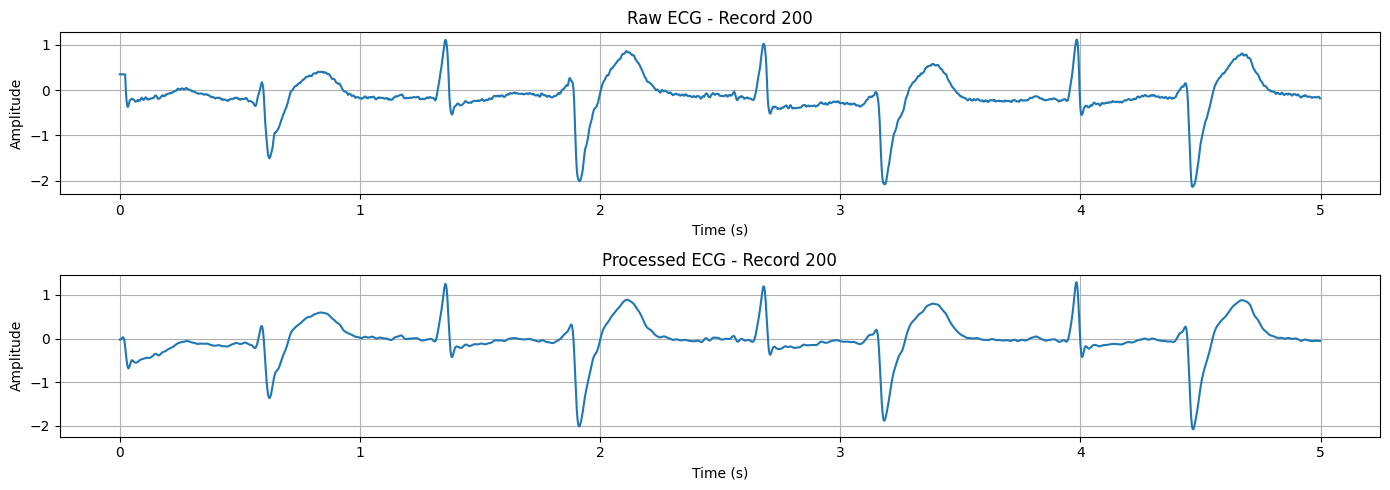

In [ ]:
def plot_raw_vs_processed(record_name='200', seconds=5):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    raw_signal = record.p_signal[:, 0]
    processed_signal = preprocess_ecg(raw_signal, fs=FS, use_notch=True, notch_freq=60.0)

    n = int(seconds * FS)
    t = np.arange(n) / FS

    plt.figure(figsize=(14, 5))

    plt.subplot(2, 1, 1)
    plt.plot(t, raw_signal[:n])
    plt.title(f"Raw ECG - Record {record_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.subplot(2, 1, 2)
    plt.plot(t, processed_signal[:n])
    plt.title(f"Processed ECG - Record {record_name}")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_raw_vs_processed(record_name='200', seconds=5)

In [ ]:
def count_symbols(record_list):
    counter = Counter()
    for rec in record_list:
        ann = wfdb.rdann(rec, 'atr', pn_dir='mitdb')
        counter.update(ann.symbol)
    return counter

symbol_counts = count_symbols(ALL_RECORDS)
print(symbol_counts)

Counter({'N': 75052, 'L': 8075, 'R': 7259, 'V': 7130, '/': 7028, 'A': 2546, '+': 1291, 'f': 982, 'F': 803, '~': 616, '!': 472, '"': 437, 'j': 229, 'x': 193, 'a': 150, '|': 132, 'E': 106, 'J': 83, 'Q': 33, 'e': 16, '[': 6, ']': 6, 'S': 2})


,record,split
0,100,train
1,101,train
2,102,test
3,103,test
4,104,test
5,105,test
6,106,test
7,107,train
8,108,train
9,109,train


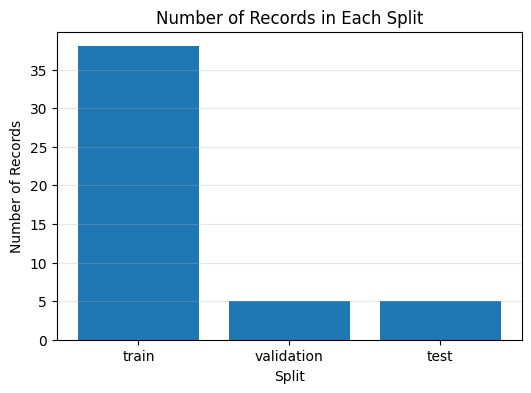

In [ ]:
split_df = pd.DataFrame({
    "record": ALL_RECORDS,
    "split": [
        "train" if r in TRAIN_RECORDS else
        "validation" if r in VAL_RECORDS else
        "test"
        for r in ALL_RECORDS
    ]
})

display(split_df)

plt.figure(figsize=(6, 4))
split_counts = split_df["split"].value_counts().reindex(["train", "validation", "test"])
plt.bar(split_counts.index, split_counts.values)
plt.title("Number of Records in Each Split")
plt.xlabel("Split")
plt.ylabel("Number of Records")
plt.grid(axis="y", alpha=0.3)
plt.show()

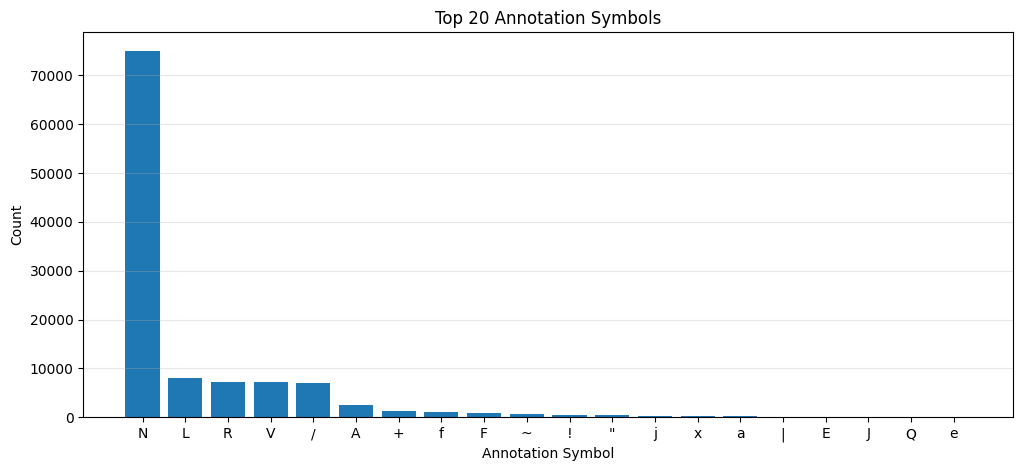

In [ ]:
top_n = 20
top_items = symbol_counts.most_common(top_n)

labels = [k for k, _ in top_items]
values = [v for _, v in top_items]

plt.figure(figsize=(12, 5))
plt.bar(labels, values)
plt.title(f"Top {top_n} Annotation Symbols")
plt.xlabel("Annotation Symbol")
plt.ylabel("Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

,symbol,count,mapped_to
0,N,75052,normal
1,L,8075,abnormal
2,R,7259,abnormal
3,V,7130,abnormal
4,/,7028,abnormal
5,A,2546,abnormal
6,+,1291,dropped
7,f,982,abnormal
8,F,803,abnormal
9,~,616,dropped


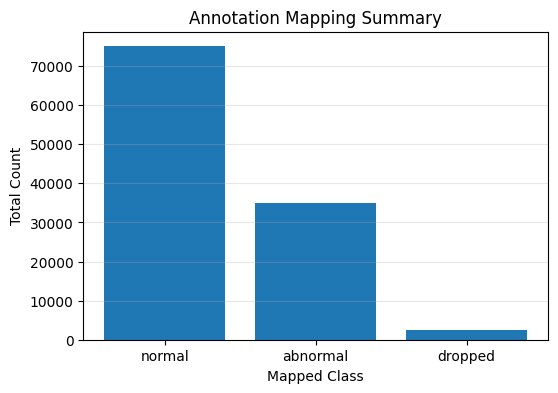

In [ ]:
mapping_rows = []

for sym, cnt in sorted(symbol_counts.items(), key=lambda x: (-x[1], x[0])):
    mapped = map_label(sym)

    if mapped is None:
        mapped_name = "dropped"
    elif mapped == 0:
        mapped_name = "normal"
    else:
        mapped_name = "abnormal"

    mapping_rows.append({
        "symbol": sym,
        "count": cnt,
        "mapped_to": mapped_name
    })

mapping_df = pd.DataFrame(mapping_rows)
display(mapping_df)

agg_map = mapping_df.groupby("mapped_to")["count"].sum().reindex(["normal", "abnormal", "dropped"]).fillna(0)

plt.figure(figsize=(6, 4))
plt.bar(agg_map.index, agg_map.values)
plt.title("Annotation Mapping Summary")
plt.xlabel("Mapped Class")
plt.ylabel("Total Count")
plt.grid(axis="y", alpha=0.3)
plt.show()

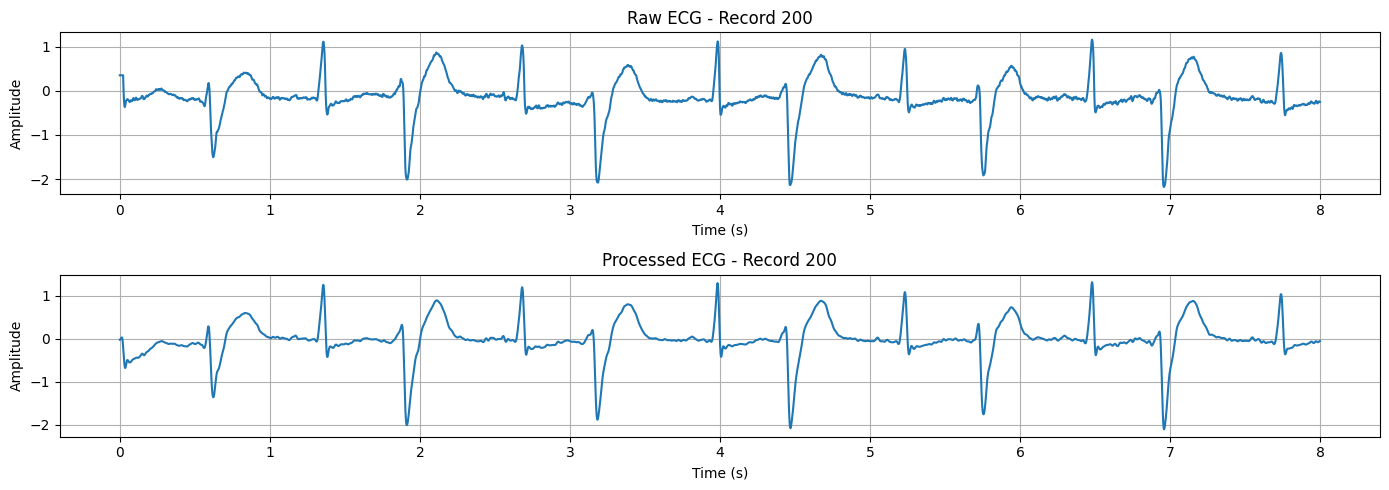

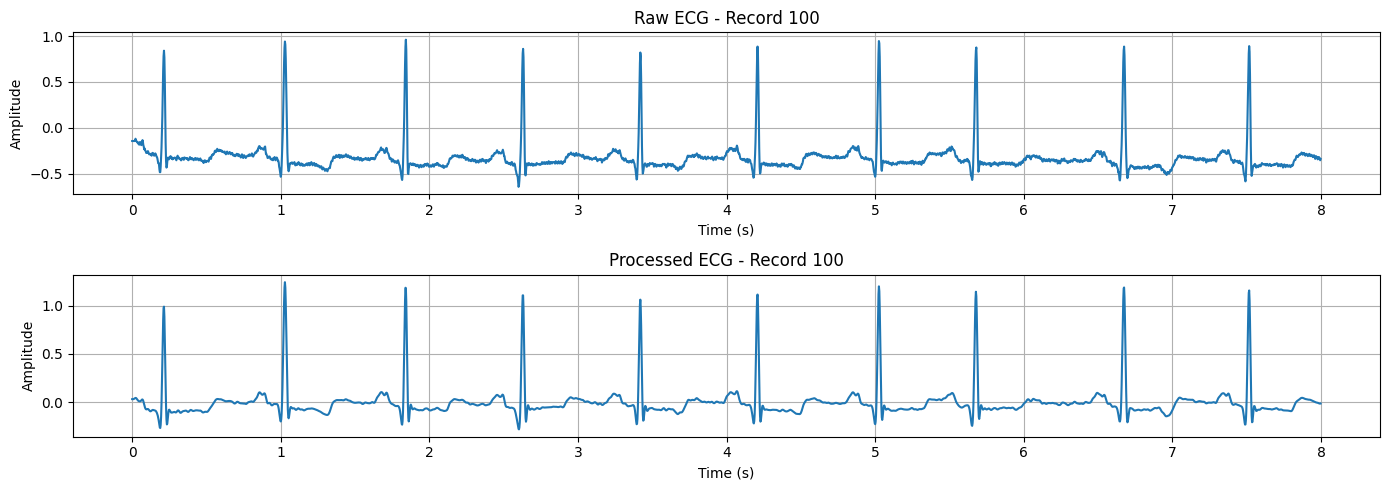

In [ ]:
plot_raw_vs_processed(record_name='200', seconds=8)
plot_raw_vs_processed(record_name='100', seconds=8)

## 5. Tạo window ECG và build dataset
Phần này chuyển tín hiệu liên tục thành các sample cố định để đưa vào CNN:
- `load_record_as_windows` đọc một record, lọc tín hiệu, cắt thành window theo `window_seconds/stride_seconds` và gán nhãn cho từng window.
- Quy tắc nhãn: nếu window chứa ít nhất một beat abnormal thì toàn bộ window được xem là `Abnormal`; nếu chỉ có beat normal thì là `Normal`.
- Mỗi window được chuẩn hóa riêng bằng z-score để mô hình học hình dạng tín hiệu thay vì độ lệch biên độ tuyệt đối.
- `build_dataset` gom window của nhiều record thành `X`, `y` và bảng `infos` để kiểm tra số liệu.


In [ ]:
def load_record_as_windows(record_name, window_seconds, stride_seconds=4.5):
    record = wfdb.rdrecord(record_name, pn_dir='mitdb')
    ann = wfdb.rdann(record_name, 'atr', pn_dir='mitdb')

    raw_signal = record.p_signal[:, 0]
    signal = preprocess_ecg(raw_signal, fs=FS, use_notch=True, notch_freq=60.0)

    ann_samples = np.array(ann.sample)
    ann_symbols = np.array(ann.symbol)

    valid_samples = []
    valid_labels = []
    dropped_symbols = 0

    for samp, sym in zip(ann_samples, ann_symbols):
        lbl = map_label(sym)
        if lbl is None:
            dropped_symbols += 1
            continue
        valid_samples.append(samp)
        valid_labels.append(lbl)

    valid_samples = np.array(valid_samples)
    valid_labels = np.array(valid_labels)

    window_len = int(window_seconds * FS)
    stride_len = int(stride_seconds * FS)

    X, y = [], []
    total_windows = 0
    skipped_no_valid_beats = 0

    for start in range(0, len(signal) - window_len + 1, stride_len):
        end = start + window_len
        total_windows += 1

        seg = signal[start:end]

        # lấy các beat nằm trong window
        mask = (valid_samples >= start) & (valid_samples < end)
        window_labels = valid_labels[mask]

        # nếu không có beat hợp lệ thì bỏ
        if len(window_labels) == 0:
            skipped_no_valid_beats += 1
            continue

        # chỉ cần 1 beat bất thường thì cả window là abnormal
        label = 1 if np.any(window_labels == 1) else 0

        # chuẩn hóa từng window
        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-8)

        X.append(seg.astype(np.float32))
        y.append(label)

    X = np.array(X)
    y = np.array(y)

    if len(X) > 0:
        X = X[..., np.newaxis]
    else:
        X = np.empty((0, window_len, 1), dtype=np.float32)

    info = {
        "record": record_name,
        "total_windows": total_windows,
        "kept_windows": len(y),
        "normal_windows": int(np.sum(y == 0)) if len(y) > 0 else 0,
        "abnormal_windows": int(np.sum(y == 1)) if len(y) > 0 else 0,
        "dropped_symbols": dropped_symbols,
        "skipped_no_valid_beats": skipped_no_valid_beats
    }

    return X, y, info

In [ ]:
def build_dataset(record_list, window_seconds, stride_seconds=4.5):
    X_all, y_all = [], []
    infos = []

    for rec in record_list:
        print(f"Processing record {rec} ...")
        X_rec, y_rec, info = load_record_as_windows(
            rec,
            window_seconds=window_seconds,
            stride_seconds=stride_seconds
        )
        infos.append(info)

        if len(X_rec) > 0:
            X_all.append(X_rec)
            y_all.append(y_rec)

    if len(X_all) > 0:
        X_all = np.concatenate(X_all, axis=0)
        y_all = np.concatenate(y_all, axis=0)
    else:
        X_all = np.empty((0, int(window_seconds * FS), 1), dtype=np.float32)
        y_all = np.array([])

    return X_all, y_all, infos

## 6. Kiểm tra phân bố window theo từng tập
Các cell trong phần này dùng để đánh giá dữ liệu sau khi cắt window:
- `inspect_window_label_distribution` build dataset cho một split và một window size, sau đó in shape, thống kê record và biểu đồ nhãn.
- `compare_window_configs_distribution` so sánh số sample và tỉ lệ abnormal giữa các window size.
- Cell chạy EDA lặp qua train/validation/test để xem mức mất cân bằng dữ liệu ở từng split.

Đọc phần này trước khi train để biết cấu hình window nào tạo đủ sample và lớp abnormal có bị quá ít hay không.


In [ ]:
def inspect_window_label_distribution(record_list, window_seconds, stride_seconds, dataset_name="Dataset"):
    X_tmp, y_tmp, infos_tmp = build_dataset(record_list, window_seconds, stride_seconds)

    print(f"{dataset_name} shapes:")
    print("X:", X_tmp.shape)
    print("y:", y_tmp.shape)

    if len(y_tmp) == 0:
        print("Không có sample nào được tạo.")
        return

    info_df = pd.DataFrame(infos_tmp)
    display(info_df)

    counts = pd.Series(y_tmp).value_counts().sort_index()
    labels = ["Normal" if idx == 0 else "Abnormal" for idx in counts.index]

    plt.figure(figsize=(6, 4))
    plt.bar(labels, counts.values)
    plt.title(f"Window Label Distribution - {dataset_name} ({window_seconds}s)")
    plt.xlabel("Label")
    plt.ylabel("Count")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    print("Tỉ lệ nhãn:")
    print(
        (pd.Series(y_tmp).value_counts(normalize=True).sort_index() * 100)
        .round(2)
        .rename(index={0: "Normal", 1: "Abnormal"})
    )

In [ ]:
def compare_window_configs_distribution(record_list, dataset_name="Dataset"):
    rows = []

    for window_name, cfg in WINDOW_CONFIGS.items():
        X_tmp, y_tmp, infos_tmp = build_dataset(
            record_list,
            window_seconds=cfg["window_seconds"],
            stride_seconds=cfg["stride_seconds"]
        )

        rows.append({
            "window_name": window_name,
            "window_seconds": cfg["window_seconds"],
            "stride_seconds": cfg["stride_seconds"],
            "n_samples": len(y_tmp),
            "normal": int(np.sum(y_tmp == 0)),
            "abnormal": int(np.sum(y_tmp == 1)),
            "abnormal_ratio_percent": float(np.mean(y_tmp == 1) * 100) if len(y_tmp) > 0 else np.nan
        })

    compare_df = pd.DataFrame(rows).sort_values("window_seconds")
    display(compare_df)

    plt.figure(figsize=(8, 4))
    plt.bar(compare_df["window_name"], compare_df["n_samples"])
    plt.title(f"Number of Samples Across Window Sizes - {dataset_name}")
    plt.xlabel("Window Configuration")
    plt.ylabel("Number of Samples")
    plt.grid(axis="y", alpha=0.3)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(compare_df["window_name"], compare_df["abnormal_ratio_percent"], marker='o')
    plt.title(f"Abnormal Ratio Across Window Sizes - {dataset_name}")
    plt.xlabel("Window Configuration")
    plt.ylabel("Abnormal Ratio (%)")
    plt.grid(True)
    plt.show()


TRAIN SET

--------------------------------------------------------------------------------
Train - 0.75s_no_overlap
--------------------------------------------------------------------------------
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219

,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,100,2407,2257,2223,34,1,150
1,101,2407,1864,1857,7,7,543
2,107,2407,2132,0,2132,3,275
3,108,2407,1760,1728,32,53,647
4,109,2407,2395,0,2395,3,12
5,111,2407,2122,0,2122,9,285
6,112,2407,2407,2405,2,11,0
7,113,2407,1792,1786,6,1,615
8,114,2407,1871,1814,57,10,536
9,115,2407,1951,1945,6,3,456


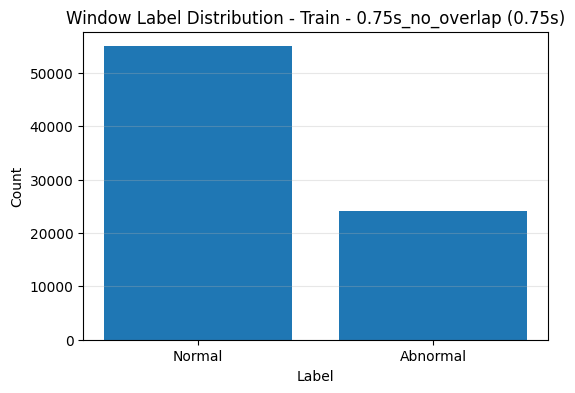

Tỉ lệ nhãn:
Normal      69.56
Abnormal    30.44
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Train - 4.5s_no_overlap
--------------------------------------------------------------------------------
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Proc

,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,100,401,401,368,33,1,0
1,101,401,401,394,7,7,0
2,107,401,401,0,401,3,0
3,108,401,401,372,29,53,0
4,109,401,401,0,401,3,0
5,111,401,401,0,401,9,0
6,112,401,401,399,2,11,0
7,113,401,401,395,6,1,0
8,114,401,401,350,51,10,0
9,115,401,401,396,5,3,0


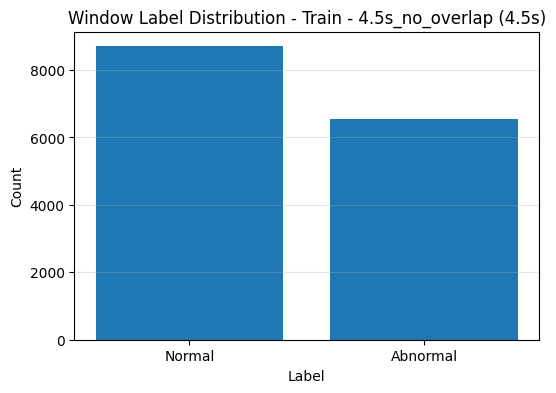

Tỉ lệ nhãn:
Normal      57.11
Abnormal    42.89
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Train - 9s_no_overlap
--------------------------------------------------------------------------------
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Proces

,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,100,200,200,169,31,1,0
1,101,200,200,194,6,7,0
2,107,200,200,0,200,3,0
3,108,200,200,171,29,53,0
4,109,200,200,0,200,3,0
5,111,200,200,0,200,9,0
6,112,200,200,198,2,11,0
7,113,200,200,194,6,1,0
8,114,200,200,156,44,10,0
9,115,200,200,196,4,3,0


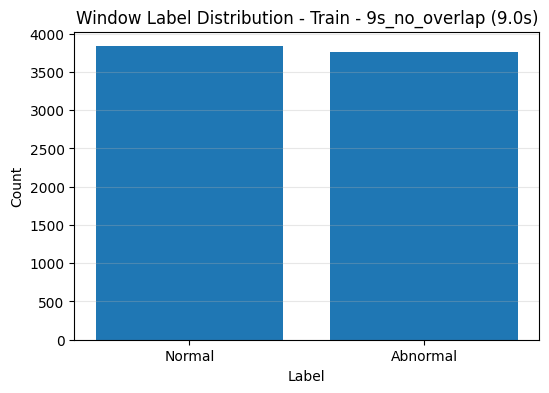

Tỉ lệ nhãn:
Normal      50.45
Abnormal    49.55
Name: proportion, dtype: float64

COMPARE WINDOW CONFIGS - TRAIN
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219 ...
Processing record 220 ...
Processing record 221 ...
Processing record 222 ...
Pro

,window_name,window_seconds,stride_seconds,n_samples,normal,abnormal,abnormal_ratio_percent
0,0.75s_no_overlap,0.75,0.75,79043,54980,24063,30.442923
1,4.5s_no_overlap,4.50,4.50,15238,8702,6536,42.892768
2,9s_no_overlap,9.00,9.00,7600,3834,3766,49.552632


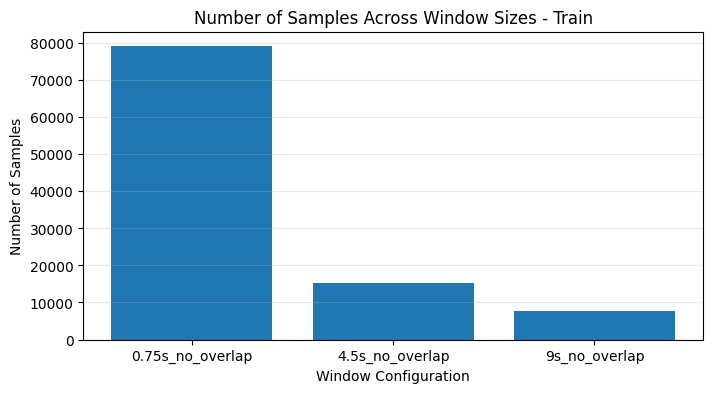

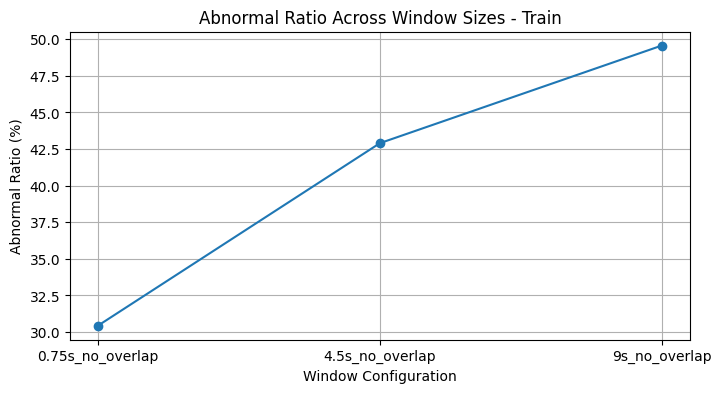


VALIDATION SET

--------------------------------------------------------------------------------
Validation - 0.75s_no_overlap
--------------------------------------------------------------------------------
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...
Validation - 0.75s_no_overlap shapes:
X: (11114, 270, 1)
y: (11114,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,200,2407,2252,1411,841,191,155
1,208,2407,2336,1144,1192,79,71
2,232,2407,1738,0,1738,36,669
3,233,2407,2381,1559,822,71,26
4,234,2407,2407,2369,38,11,0


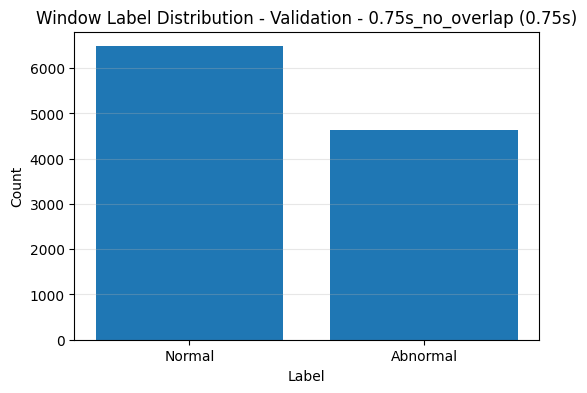

Tỉ lệ nhãn:
Normal      58.33
Abnormal    41.67
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Validation - 4.5s_no_overlap
--------------------------------------------------------------------------------
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...
Validation - 4.5s_no_overlap shapes:
X: (2004, 1620, 1)
y: (2004,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,200,401,401,77,324,191,0
1,208,401,401,5,396,79,0
2,232,401,400,0,400,36,1
3,233,401,401,16,385,71,0
4,234,401,401,391,10,11,0


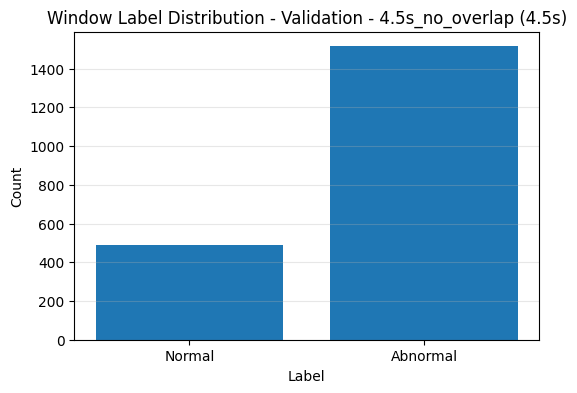

Tỉ lệ nhãn:
Normal      24.4
Abnormal    75.6
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Validation - 9s_no_overlap
--------------------------------------------------------------------------------
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...
Validation - 9s_no_overlap shapes:
X: (1000, 3240, 1)
y: (1000,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,200,200,200,15,185,191,0
1,208,200,200,1,199,79,0
2,232,200,200,0,200,36,0
3,233,200,200,0,200,71,0
4,234,200,200,193,7,11,0


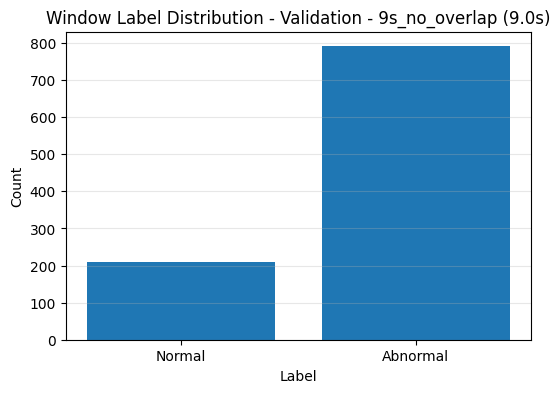

Tỉ lệ nhãn:
Normal      20.9
Abnormal    79.1
Name: proportion, dtype: float64

COMPARE WINDOW CONFIGS - VALIDATION
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...
Processing record 200 ...
Processing record 208 ...
Processing record 232 ...
Processing record 233 ...
Processing record 234 ...


,window_name,window_seconds,stride_seconds,n_samples,normal,abnormal,abnormal_ratio_percent
0,0.75s_no_overlap,0.75,0.75,11114,6483,4631,41.668166
1,4.5s_no_overlap,4.50,4.50,2004,489,1515,75.598802
2,9s_no_overlap,9.00,9.00,1000,209,791,79.100000


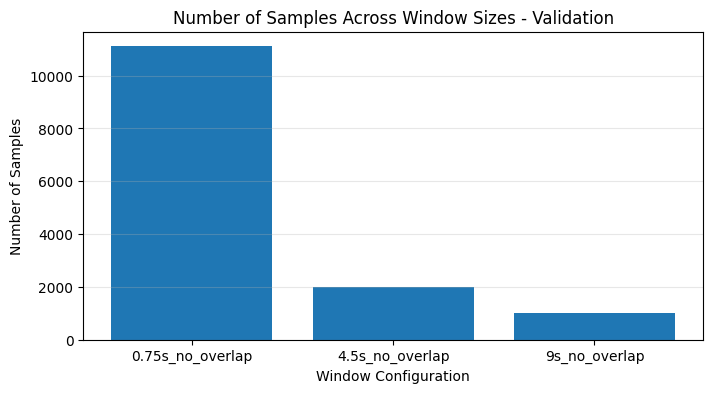

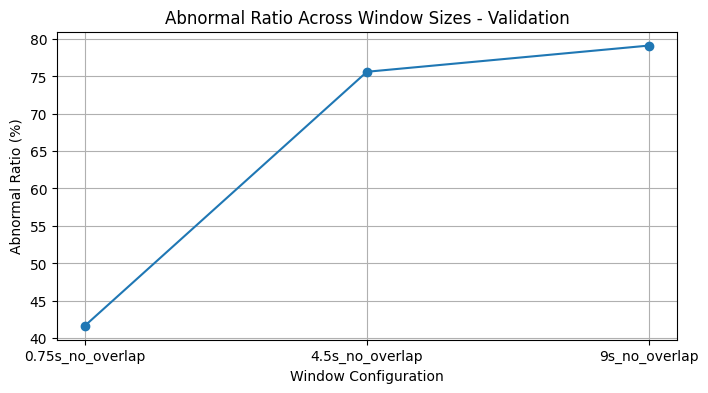


TEST SET

--------------------------------------------------------------------------------
Test - 0.75s_no_overlap
--------------------------------------------------------------------------------
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...
Test - 0.75s_no_overlap shapes:
X: (10736, 270, 1)
y: (10736,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,102,2407,2187,99,2088,5,220
1,103,2407,2083,2081,2,7,324
2,104,2407,2205,159,2046,100,202
3,105,2407,2389,2318,71,94,18
4,106,2407,1872,1383,489,71,535


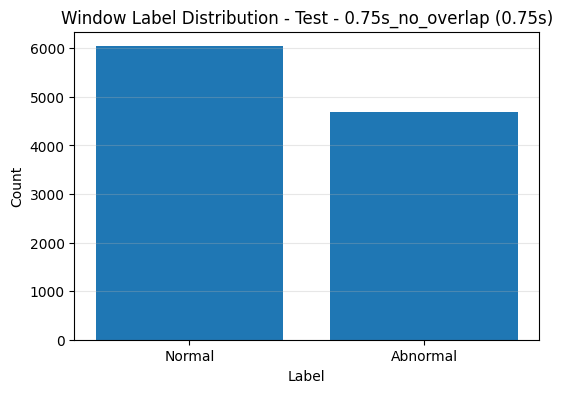

Tỉ lệ nhãn:
Normal      56.26
Abnormal    43.74
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Test - 4.5s_no_overlap
--------------------------------------------------------------------------------
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...
Test - 4.5s_no_overlap shapes:
X: (2004, 1620, 1)
y: (2004,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,102,401,401,15,386,5,0
1,103,401,401,399,2,7,0
2,104,401,400,7,393,100,1
3,105,401,401,336,65,94,0
4,106,401,401,197,204,71,0


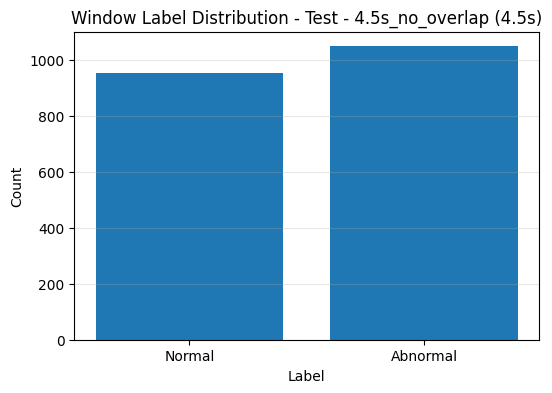

Tỉ lệ nhãn:
Normal      47.6
Abnormal    52.4
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Test - 9s_no_overlap
--------------------------------------------------------------------------------
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...
Test - 9s_no_overlap shapes:
X: (1000, 3240, 1)
y: (1000,)


,record,total_windows,kept_windows,normal_windows,abnormal_windows,dropped_symbols,skipped_no_valid_beats
0,102,200,200,6,194,5,0
1,103,200,200,198,2,7,0
2,104,200,200,3,197,100,0
3,105,200,200,139,61,94,0
4,106,200,200,93,107,71,0


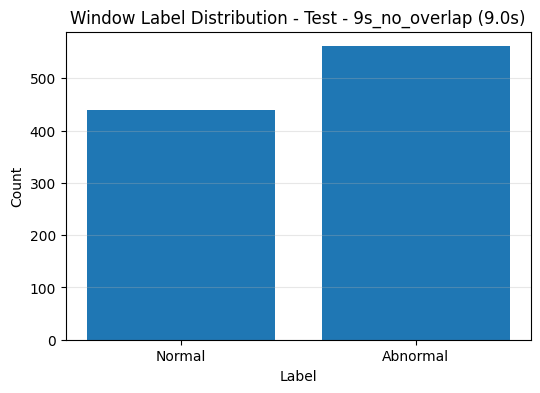

Tỉ lệ nhãn:
Normal      43.9
Abnormal    56.1
Name: proportion, dtype: float64

COMPARE WINDOW CONFIGS - TEST
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...
Processing record 102 ...
Processing record 103 ...
Processing record 104 ...
Processing record 105 ...
Processing record 106 ...


,window_name,window_seconds,stride_seconds,n_samples,normal,abnormal,abnormal_ratio_percent
0,0.75s_no_overlap,0.75,0.75,10736,6040,4696,43.740686
1,4.5s_no_overlap,4.50,4.50,2004,954,1050,52.395210
2,9s_no_overlap,9.00,9.00,1000,439,561,56.100000


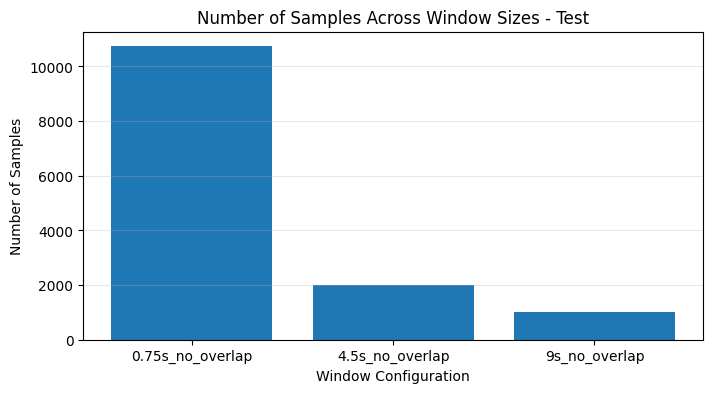

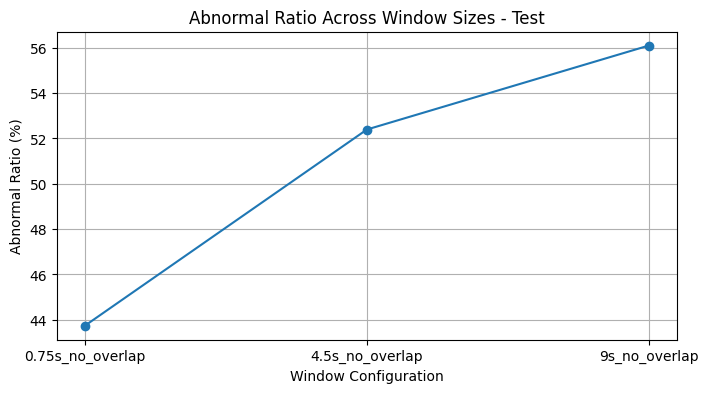

In [ ]:
# EDA: kiểm tra phân bố nhãn cho toàn bộ window size trên train / validation / test

for split_name, record_list in [
    ("Train", TRAIN_RECORDS),
    ("Validation", VAL_RECORDS),
    ("Test", TEST_RECORDS),
]:
    print("\n" + "=" * 100)
    print(f"{split_name.upper()} SET")
    print("=" * 100)

    for window_name, cfg in WINDOW_CONFIGS.items():
        print("\n" + "-" * 80)
        print(f"{split_name} - {window_name}")
        print("-" * 80)

        inspect_window_label_distribution(
            record_list=record_list,
            window_seconds=cfg["window_seconds"],
            stride_seconds=cfg["stride_seconds"],
            dataset_name=f"{split_name} - {window_name}"
        )

    print("\n" + "=" * 100)
    print(f"COMPARE WINDOW CONFIGS - {split_name.upper()}")
    print("=" * 100)

    compare_window_configs_distribution(
        record_list=record_list,
        dataset_name=split_name
    )

## 7. Bảng tổng hợp nhãn thủ công (tùy chọn)
Cell này tạo bảng dạng Excel cho số lượng `normal/abnormal` theo từng split và window size.

Lưu ý: cell này chỉ chạy được nếu trước đó đã có sẵn các biến `y_train_45`, `y_val_45`, `y_test_45`, `y_train_9`, `y_val_9`, `y_test_9`. Nếu chạy notebook tuần tự từ đầu mà chưa tạo các biến này, có thể bỏ qua cell này và dùng kết quả từ phần 6 hoặc phần 11.


In [ ]:
import pandas as pd
import numpy as np

# =========================================================
# HÀM ĐẾM NORMAL / ABNORMAL
# Quy ước:
#   normal   = 0
#   abnormal = 1
# =========================================================
def count_normal_abnormal(y):
    y = np.asarray(y)
    normal_count = np.sum(y == 0)
    abnormal_count = np.sum(y == 1)
    return normal_count, abnormal_count

# =========================================================
# ĐẾM CHO TỪNG TẬP
# thay các biến y_* bằng label thật của mày
# =========================================================
n_45_train, a_45_train = count_normal_abnormal(y_train_45)
n_45_val,   a_45_val   = count_normal_abnormal(y_val_45)
n_45_test,  a_45_test  = count_normal_abnormal(y_test_45)

n_9_train,  a_9_train  = count_normal_abnormal(y_train_9)
n_9_val,    a_9_val    = count_normal_abnormal(y_val_9)
n_9_test,   a_9_test   = count_normal_abnormal(y_test_9)

# =========================================================
# TẠO BẢNG GIỐNG KIỂU EXCEL
# =========================================================
summary_df = pd.DataFrame(
    [
        [n_45_train, n_45_val, n_45_test, n_9_train, n_9_val, n_9_test],
        [a_45_train, a_45_val, a_45_test, a_9_train, a_9_val, a_9_test],
    ],
    index=["normal", "abnormal"],
    columns=pd.MultiIndex.from_tuples([
        ("4.5s", "train"),
        ("4.5s", "val"),
        ("4.5s", "test"),
        ("9s",   "train"),
        ("9s",   "val"),
        ("9s",   "test"),
    ])
)

display(summary_df)

## 8. Trực quan hóa window mẫu
Phần này vẽ các window ECG đã chuẩn hóa để kiểm tra trực quan sample trước khi đưa vào CNN:
- `plot_example_segments` chọn ngẫu nhiên một số window bất kỳ.
- `plot_examples_by_class` chọn riêng một số window `Normal` và `Abnormal` để so sánh.
- Cell cuối build sample từ train set cho các cấu hình no-overlap và vẽ ví dụ từng lớp.

Mục tiêu là kiểm tra xem window có đúng độ dài, tín hiệu có được chuẩn hóa ổn định và nhãn có tạo ra ví dụ phân biệt được hay không.


In [ ]:
def plot_example_segments(X, y, n_examples=6, title_prefix=""):
    if len(X) == 0:
        print("No samples to plot.")
        return

    n_examples = min(n_examples, len(X))
    idxs = np.random.choice(len(X), size=n_examples, replace=False)

    plt.figure(figsize=(14, 2.5 * n_examples))
    for i, idx in enumerate(idxs, 1):
        plt.subplot(n_examples, 1, i)
        plt.plot(X[idx].squeeze())
        label_name = "Normal" if y[idx] == 0 else "Abnormal"
        plt.title(f"{title_prefix} Sample #{idx} - Label: {label_name}")
        plt.xlabel("Time step")
        plt.ylabel("Normalized amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

In [ ]:
def plot_examples_by_class(X, y, n_each=3, title_prefix=""):
    normal_idx = np.where(y == 0)[0]
    abnormal_idx = np.where(y == 1)[0]

    chosen_normal = np.random.choice(normal_idx, size=min(n_each, len(normal_idx)), replace=False) if len(normal_idx) > 0 else []
    chosen_abnormal = np.random.choice(abnormal_idx, size=min(n_each, len(abnormal_idx)), replace=False) if len(abnormal_idx) > 0 else []

    chosen = list(chosen_normal) + list(chosen_abnormal)

    if len(chosen) == 0:
        print("Không có sample để vẽ.")
        return

    plt.figure(figsize=(14, 2.5 * len(chosen)))
    for i, idx in enumerate(chosen, 1):
        plt.subplot(len(chosen), 1, i)
        plt.plot(X[idx].squeeze())
        label_name = "Normal" if y[idx] == 0 else "Abnormal"
        plt.title(f"{title_prefix} Sample #{idx} - Label: {label_name}")
        plt.xlabel("Time step")
        plt.ylabel("Normalized amplitude")
        plt.grid(True)

    plt.tight_layout()
    plt.show()

Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219 ...
Processing record 220 ...
Processing record 221 ...
Processing record 222 ...
Processing record 223 ...
Processing record 228 ...
Processing record 230 ...
Processing record 231 ...


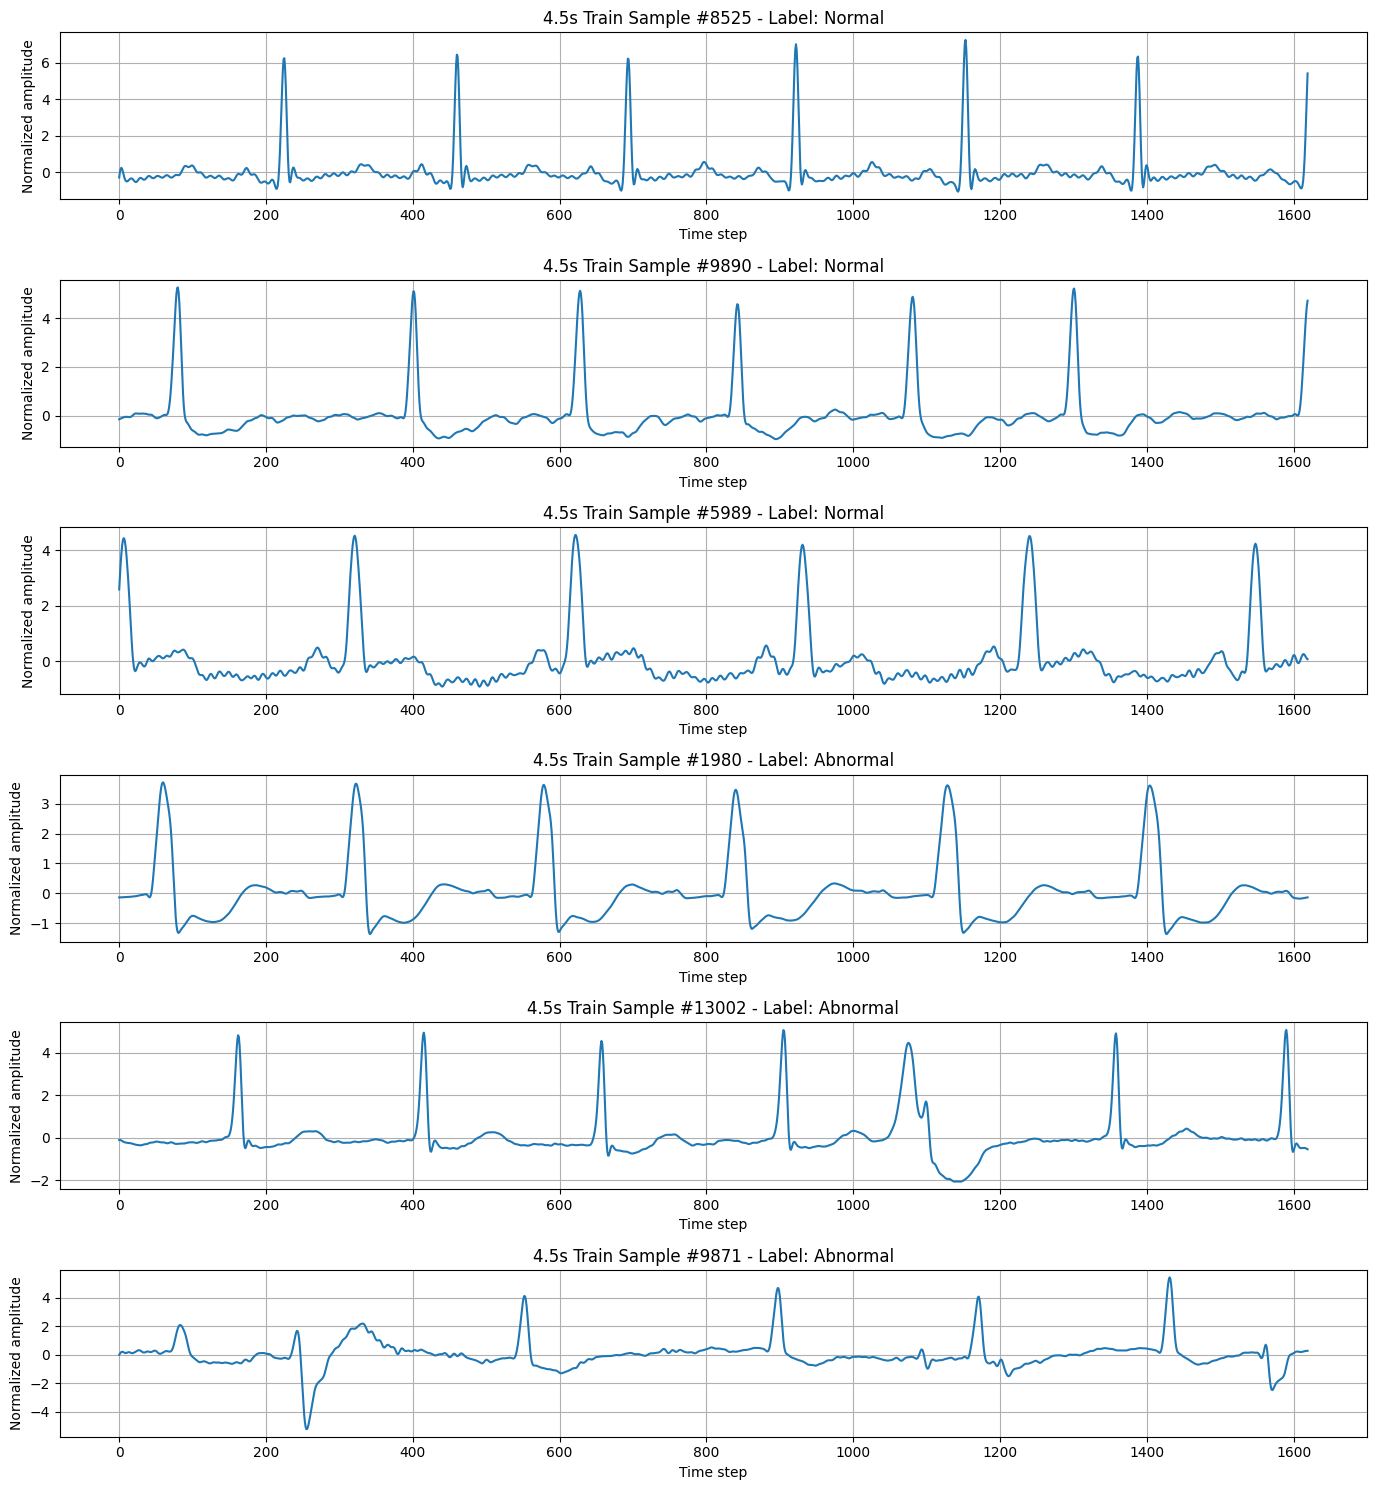

In [ ]:
# Visualize examples for all no-overlap window settings
VIS_WINDOW_CONFIGS = [
    ("0.75s_no_overlap", 0.75, 0.75),
    ("4.5s_no_overlap", 4.5, 4.5),
    ("9s_no_overlap", 9.0, 9.0),
]

for window_name, window_seconds, stride_seconds in VIS_WINDOW_CONFIGS:
    X_vis, y_vis, _ = build_dataset(
        TRAIN_RECORDS,
        window_seconds=window_seconds,
        stride_seconds=stride_seconds
    )

    plot_examples_by_class(
        X_vis,
        y_vis,
        n_each=3,
        title_prefix=f"{window_name} Train"
    )

## 9. Định nghĩa mô hình CNN 1D
Phần này định nghĩa kiến trúc và các hàm hỗ trợ cho quá trình training:
- `build_cnn_model` nhận độ dài window và tạo mạng Conv1D nhiều tầng.
- Các block Conv1D + BatchNorm + Pooling học đặc trưng cục bộ theo thời gian.
- `GlobalAveragePooling1D` gom đặc trưng theo trục thời gian trước khi qua Dense layer.
- Output sigmoid trả về xác suất window thuộc lớp `Abnormal`.
- `print_class_distribution` và `plot_history` hỗ trợ đọc phân bố nhãn và quá trình train/validation.


In [ ]:
def build_cnn_model(input_len):
    inp = tf.keras.Input(shape=(input_len, 1), name='ecg_input')

    x = tf.keras.layers.Conv1D(32, kernel_size=7, padding='same', activation='relu')(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = tf.keras.layers.Conv1D(64, kernel_size=5, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = tf.keras.layers.Conv1D(128, kernel_size=5, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)

    x = tf.keras.layers.Conv1D(256, kernel_size=3, padding='same', activation='relu')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)

    x = tf.keras.layers.Dense(128, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.4)(x)

    x = tf.keras.layers.Dense(64, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.Model(inputs=inp, outputs=out)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )

    return model

In [ ]:
def print_class_distribution(y, name="Dataset"):
    if len(y) == 0:
        print(f"{name}: empty")
        return

    normal = np.sum(y == 0)
    abnormal = np.sum(y == 1)
    total = len(y)

    print(f"{name} distribution:")
    print(f"  Normal   : {normal} ({normal/total:.2%})")
    print(f"  Abnormal : {abnormal} ({abnormal/total:.2%})")
    print(f"  Total    : {total}")

def plot_history(history, title_prefix=""):
    hist = history.history
    epochs = range(1, len(hist['loss']) + 1)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, hist['loss'], label='Train loss')
    plt.plot(epochs, hist['val_loss'], label='Val loss')
    plt.title(f'{title_prefix} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, hist['accuracy'], label='Train acc')
    plt.plot(epochs, hist['val_accuracy'], label='Val acc')
    plt.title(f'{title_prefix} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, hist['auc'], label='Train AUC')
    plt.plot(epochs, hist['val_auc'], label='Val AUC')
    plt.title(f'{title_prefix} AUC')
    plt.xlabel('Epoch')
    plt.ylabel('AUC')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

## 10. Huấn luyện và đánh giá
`run_experiment` là hàm chạy toàn bộ pipeline cho một cấu hình window:
- Build train/validation/test từ danh sách record đã chia.
- In shape và phân bố nhãn để kiểm tra dữ liệu đầu vào.
- Tính `class_weight` để giảm ảnh hưởng của mất cân bằng lớp.
- Huấn luyện với `EarlyStopping` và `ReduceLROnPlateau`.
- Dự đoán trên test set, tính accuracy, precision, recall, F1-score và confusion matrix.

Cell chạy experiment bên dưới lặp qua tất cả cấu hình trong `WINDOW_CONFIGS` và lưu kết quả vào `all_results`.


In [ ]:
def run_experiment(window_name, window_seconds, stride_seconds=4.5, epochs=15, batch_size=64):
    print("=" * 80)
    print(f"RUNNING TSC WINDOW VERSION: {window_name} "
          f"(window={window_seconds}s, stride={stride_seconds}s)")
    print("=" * 80)

    X_train, y_train, train_infos = build_dataset(TRAIN_RECORDS, window_seconds, stride_seconds)
    X_val, y_val, val_infos = build_dataset(VAL_RECORDS, window_seconds, stride_seconds)
    X_test, y_test, test_infos = build_dataset(TEST_RECORDS, window_seconds, stride_seconds)

    print("\nShapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
    print("X_test :", X_test.shape,  "y_test :", y_test.shape)

    print()
    print_class_distribution(y_train, "Train")
    print_class_distribution(y_val, "Validation")
    print_class_distribution(y_test, "Test")

    plot_example_segments(X_train, y_train, n_examples=6, title_prefix=f"{window_name} Train")

    classes = np.unique(y_train)
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=classes,
        y=y_train
    )
    class_weight_dict = {int(c): float(w) for c, w in zip(classes, class_weights)}
    print("\nClass weights:", class_weight_dict)

    model = build_cnn_model(input_len=X_train.shape[1])
    model.summary()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=5,
            restore_best_weights=True
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )

    y_prob = model.predict(X_test).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print("\n" + "-" * 80)
    print("TEST RESULTS")
    print("-" * 80)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4, zero_division=0))

    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Normal", "Abnormal"])
    disp.plot(values_format='d')
    plt.title(f"Confusion Matrix - {window_name}")
    plt.grid(False)
    plt.show()

    plot_history(history, title_prefix=window_name)

    return {
        "window_name": window_name,
        "window_seconds": window_seconds,
        "window_samples": X_train.shape[1],
        "stride_seconds": stride_seconds,
        "train_samples": len(X_train),
        "val_samples": len(X_val),
        "test_samples": len(X_test),
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "confusion_matrix": cm,
        "history": history.history,
        "model": model,
        "train_infos": train_infos,
        "val_infos": val_infos,
        "test_infos": test_infos,
        "y_test": y_test,
        "y_pred": y_pred,
        "history": history
    }

RUNNING TSC WINDOW VERSION: 0.75s_no_overlap (window=0.75s, stride=0.75s)
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219 ...
Processing record 220 ...
Processing record 221 ...
Processing record 222 ...
Processing record 223 ...
Processing recor

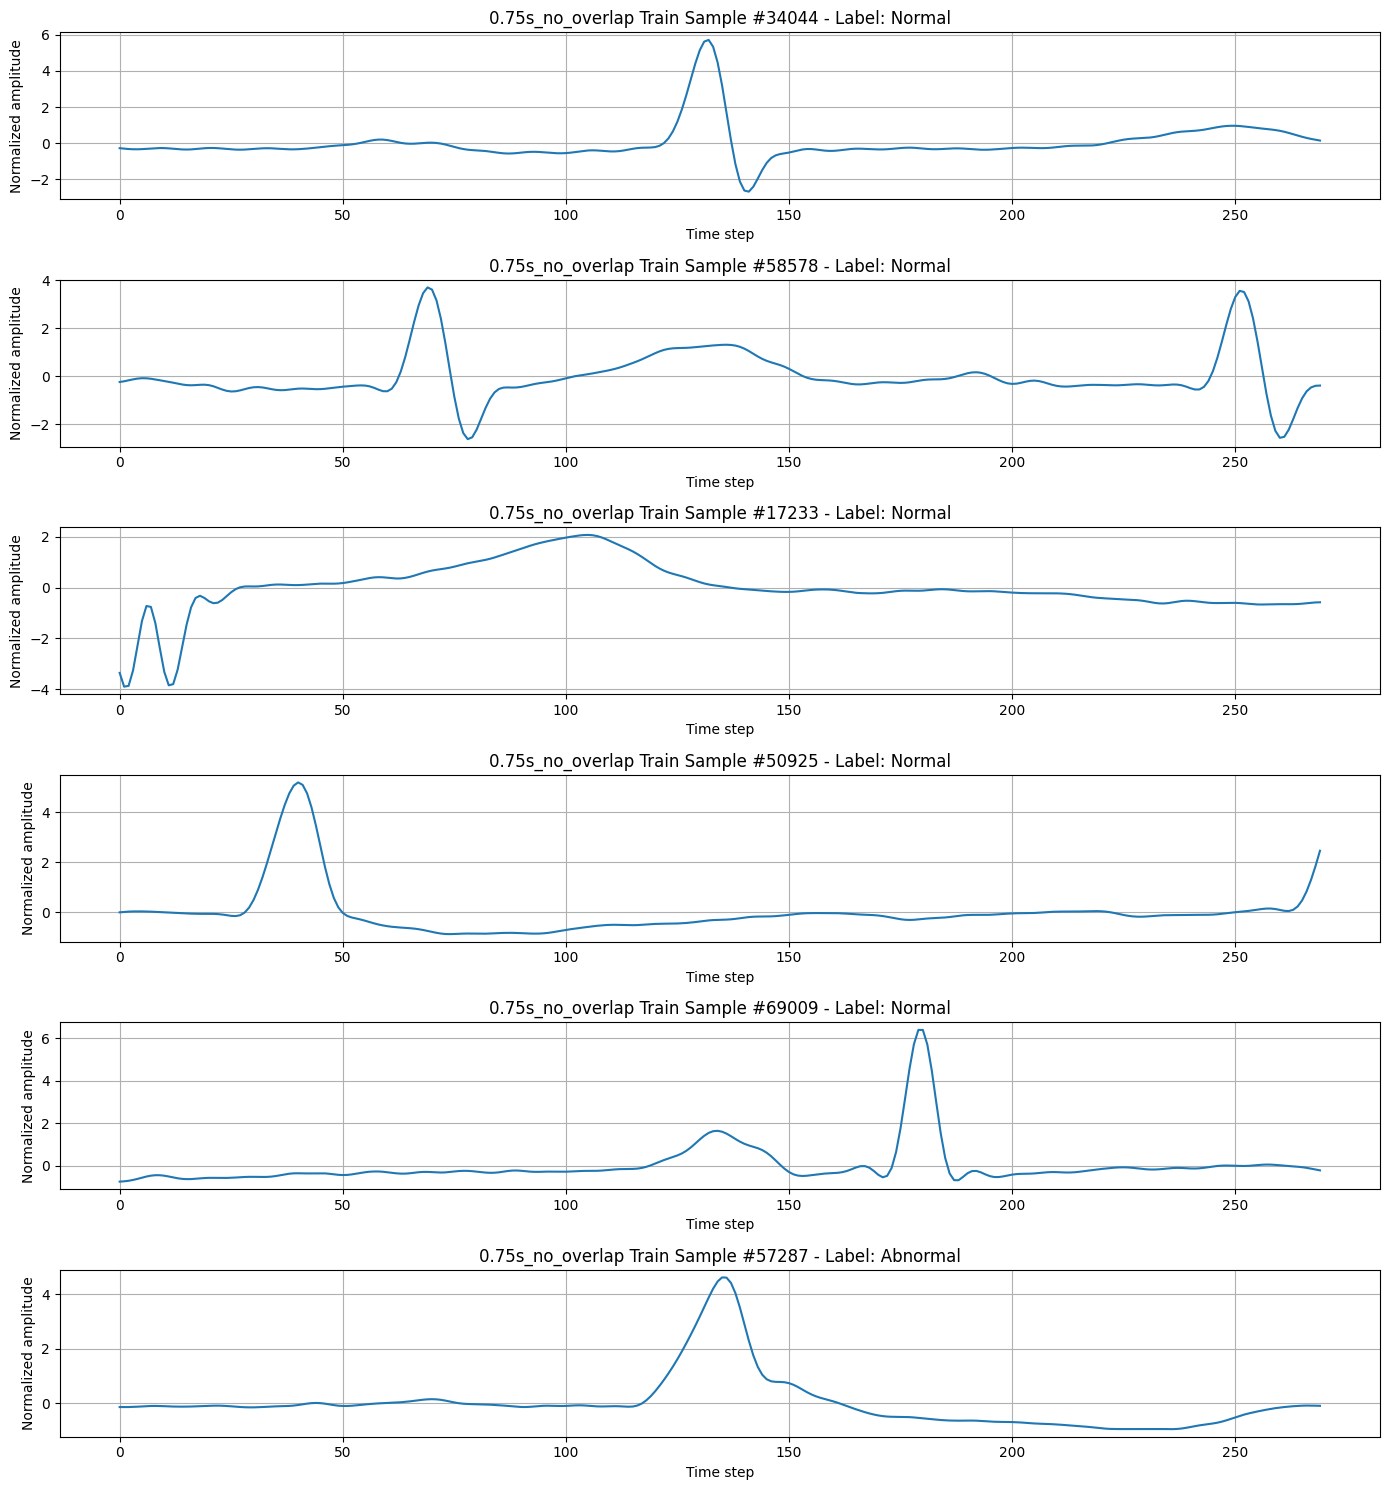


Class weights: {0: 0.7188341214987268, 1: 1.6424178198894568}


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 270, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 270, 32)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 270, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 135, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 135, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 135, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 67, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 67, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 67, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 33, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 33, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 33, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,345 (755.25 KB)

 Trainable params: 192,385 (751.50 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 25s 12ms/step - accuracy: 0.9467 - auc: 0.9806 - loss: 0.1679 - val_accuracy: 0.8126 - val_auc: 0.8644 - val_loss: 0.5128 - learning_rate: 0.0010
Epoch 2/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9683 - auc: 0.9906 - loss: 0.1077 - val_accuracy: 0.8346 - val_auc: 0.9228 - val_loss: 0.4075 - learning_rate: 0.0010
Epoch 3/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9754 - auc: 0.9931 - loss: 0.0875 - val_accuracy: 0.8858 - val_auc: 0.9571 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 4/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9782 - auc: 0.9948 - loss: 0.0757 - val_accuracy: 0.7805 - val_auc: 0.8651 - val_loss: 0.7310 - learning_rate: 0.0010
Epoch 5/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9791 - auc: 0.9953 - loss: 0.0726 - val_accuracy: 0.8167 - val_auc: 0.8946 - val_loss: 0.5171 - learning_rate: 0.0010
Epoch 6/15
1236/1236 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.

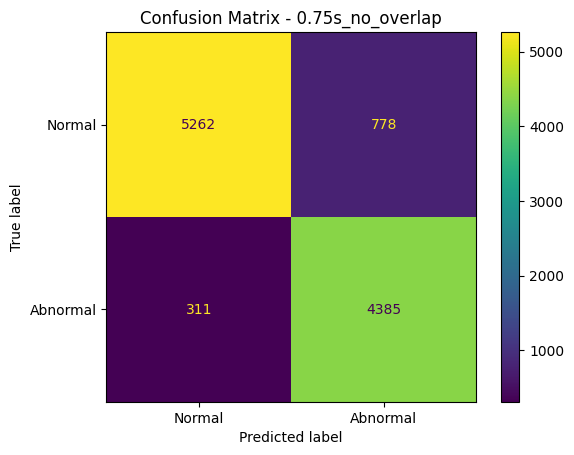

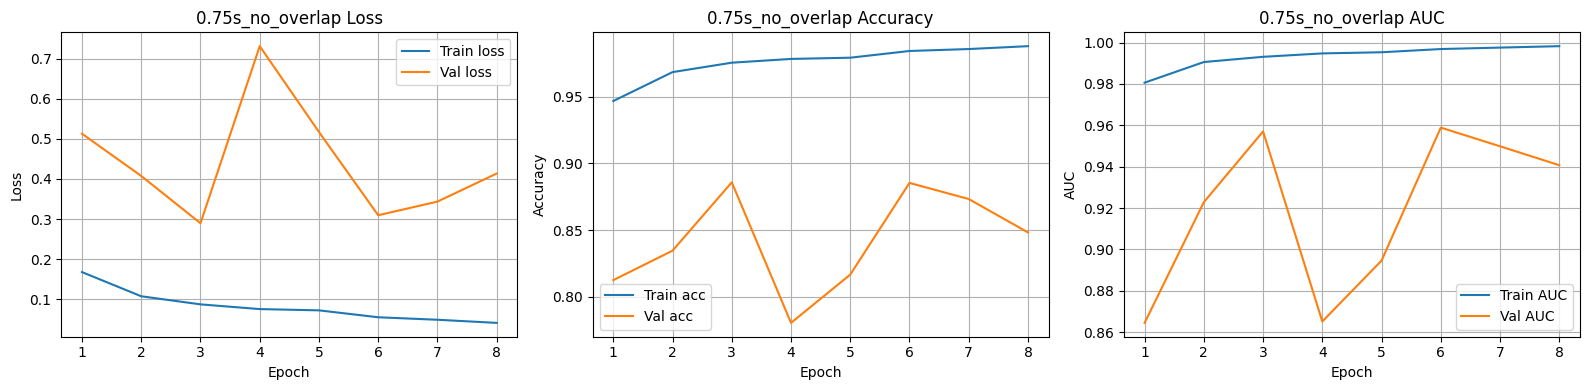

RUNNING TSC WINDOW VERSION: 4.5s_no_overlap (window=4.5s, stride=4.5s)
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219 ...
Processing record 220 ...
Processing record 221 ...
Processing record 222 ...
Processing record 223 ...
Processing record 2

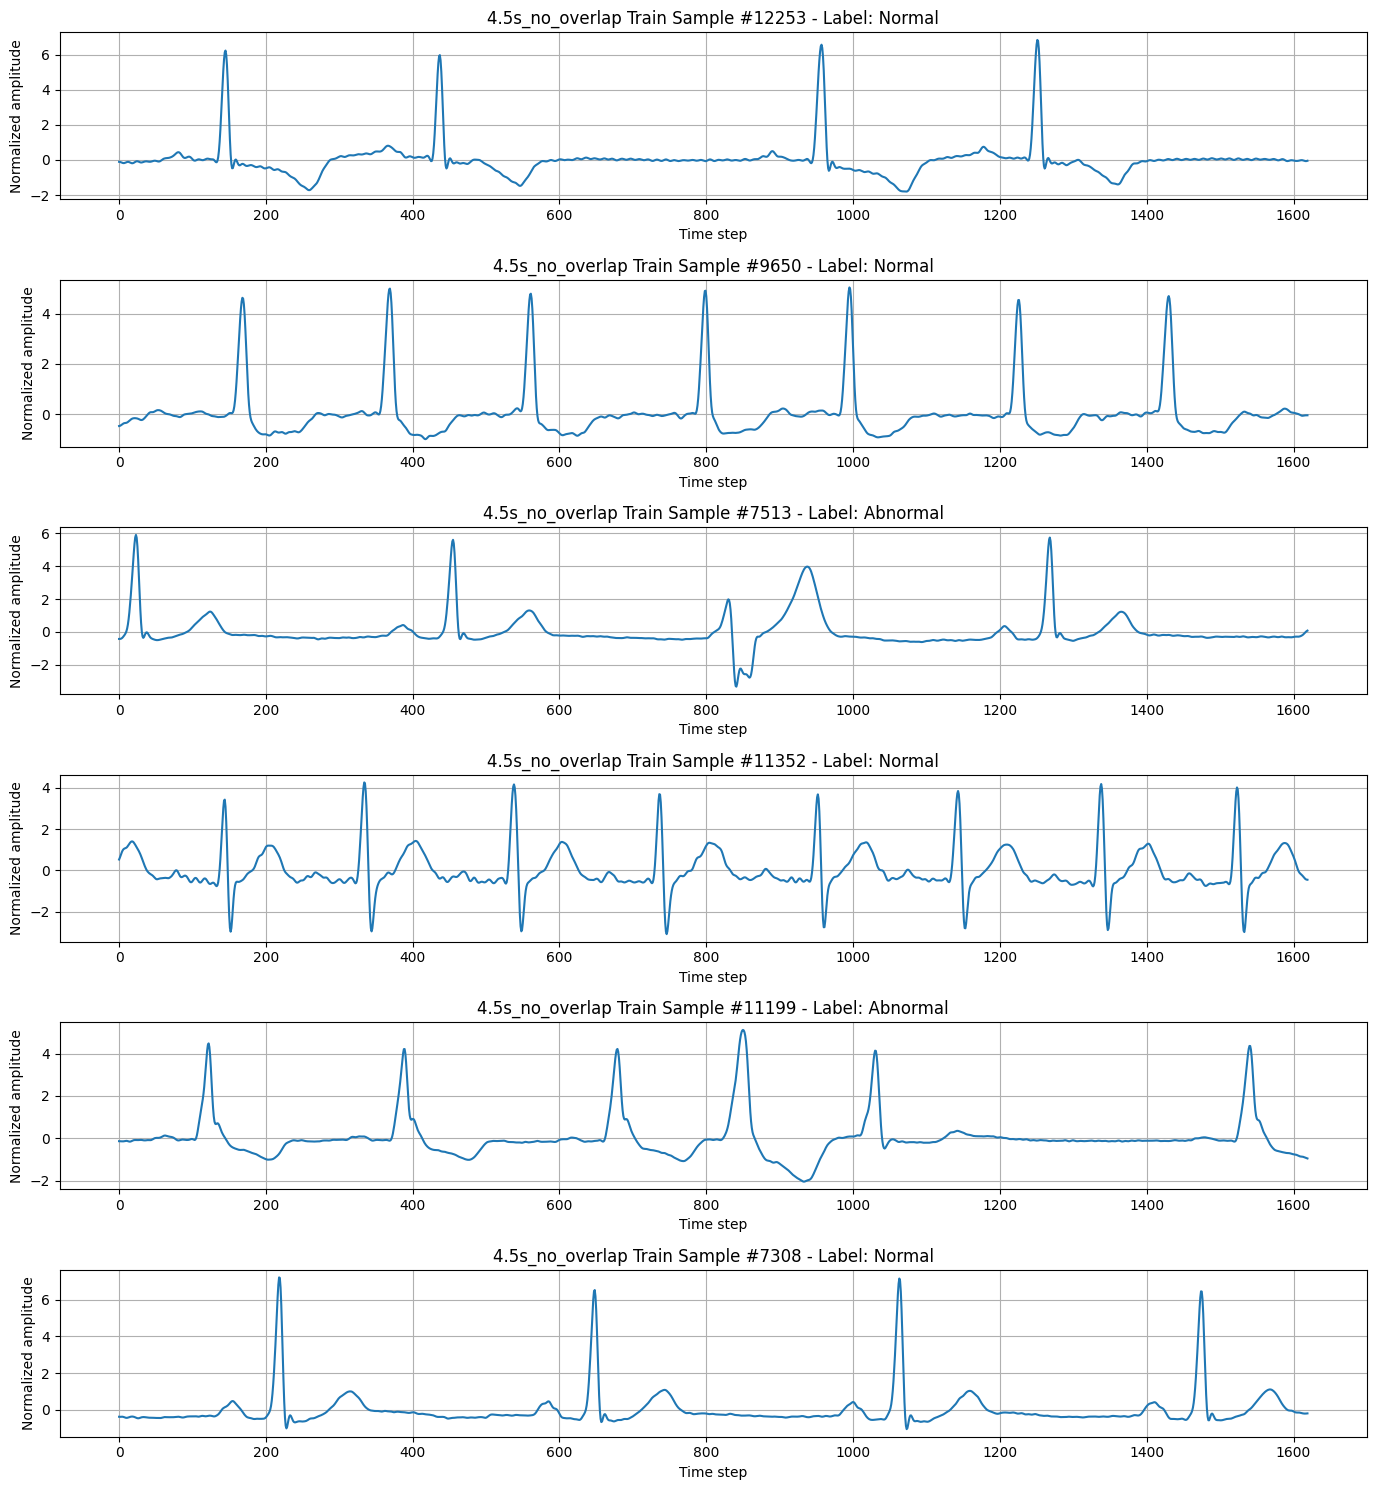


Class weights: {0: 0.8755458515283843, 1: 1.1656976744186047}


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 1620, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 1620, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 1620, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 810, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 810, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 810, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 405, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 405, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 405, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 202, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_7 (Conv1D)               │ (None, 202, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 202, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,345 (755.25 KB)

 Trainable params: 192,385 (751.50 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 23s 58ms/step - accuracy: 0.8903 - auc: 0.9498 - loss: 0.2859 - val_accuracy: 0.9551 - val_auc: 0.9917 - val_loss: 0.1700 - learning_rate: 0.0010
Epoch 2/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9271 - auc: 0.9723 - loss: 0.2028 - val_accuracy: 0.9356 - val_auc: 0.9841 - val_loss: 0.1893 - learning_rate: 0.0010
Epoch 3/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9354 - auc: 0.9774 - loss: 0.1784 - val_accuracy: 0.9541 - val_auc: 0.9890 - val_loss: 0.1098 - learning_rate: 0.0010
Epoch 4/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9417 - auc: 0.9806 - loss: 0.1638 - val_accuracy: 0.9591 - val_auc: 0.9919 - val_loss: 0.1072 - learning_rate: 0.0010
Epoch 5/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.9487 - auc: 0.9838 - loss: 0.1472 - val_accuracy: 0.9047 - val_auc: 0.9728 - val_loss: 0.2111 - learning_rate: 0.0010
Epoch 6/15
239/239 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.9478 - 

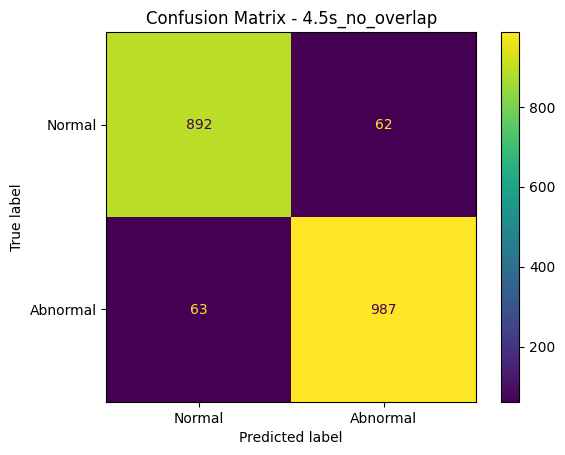

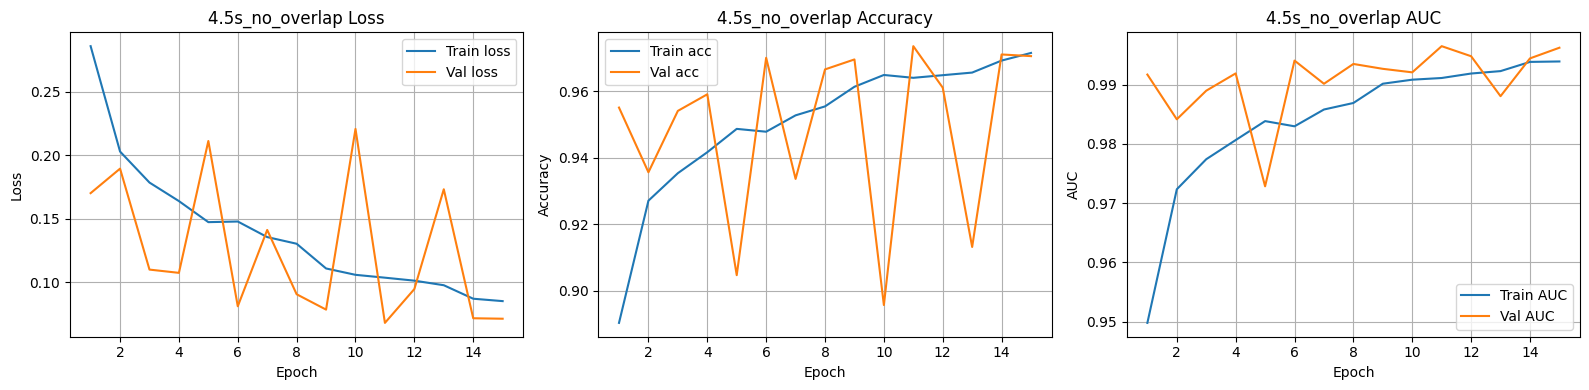

RUNNING TSC WINDOW VERSION: 9s_no_overlap (window=9.0s, stride=9.0s)
Processing record 100 ...
Processing record 101 ...
Processing record 107 ...
Processing record 108 ...
Processing record 109 ...
Processing record 111 ...
Processing record 112 ...
Processing record 113 ...
Processing record 114 ...
Processing record 115 ...
Processing record 116 ...
Processing record 117 ...
Processing record 118 ...
Processing record 119 ...
Processing record 121 ...
Processing record 122 ...
Processing record 123 ...
Processing record 124 ...
Processing record 201 ...
Processing record 202 ...
Processing record 203 ...
Processing record 205 ...
Processing record 207 ...
Processing record 209 ...
Processing record 210 ...
Processing record 212 ...
Processing record 213 ...
Processing record 214 ...
Processing record 215 ...
Processing record 217 ...
Processing record 219 ...
Processing record 220 ...
Processing record 221 ...
Processing record 222 ...
Processing record 223 ...
Processing record 228

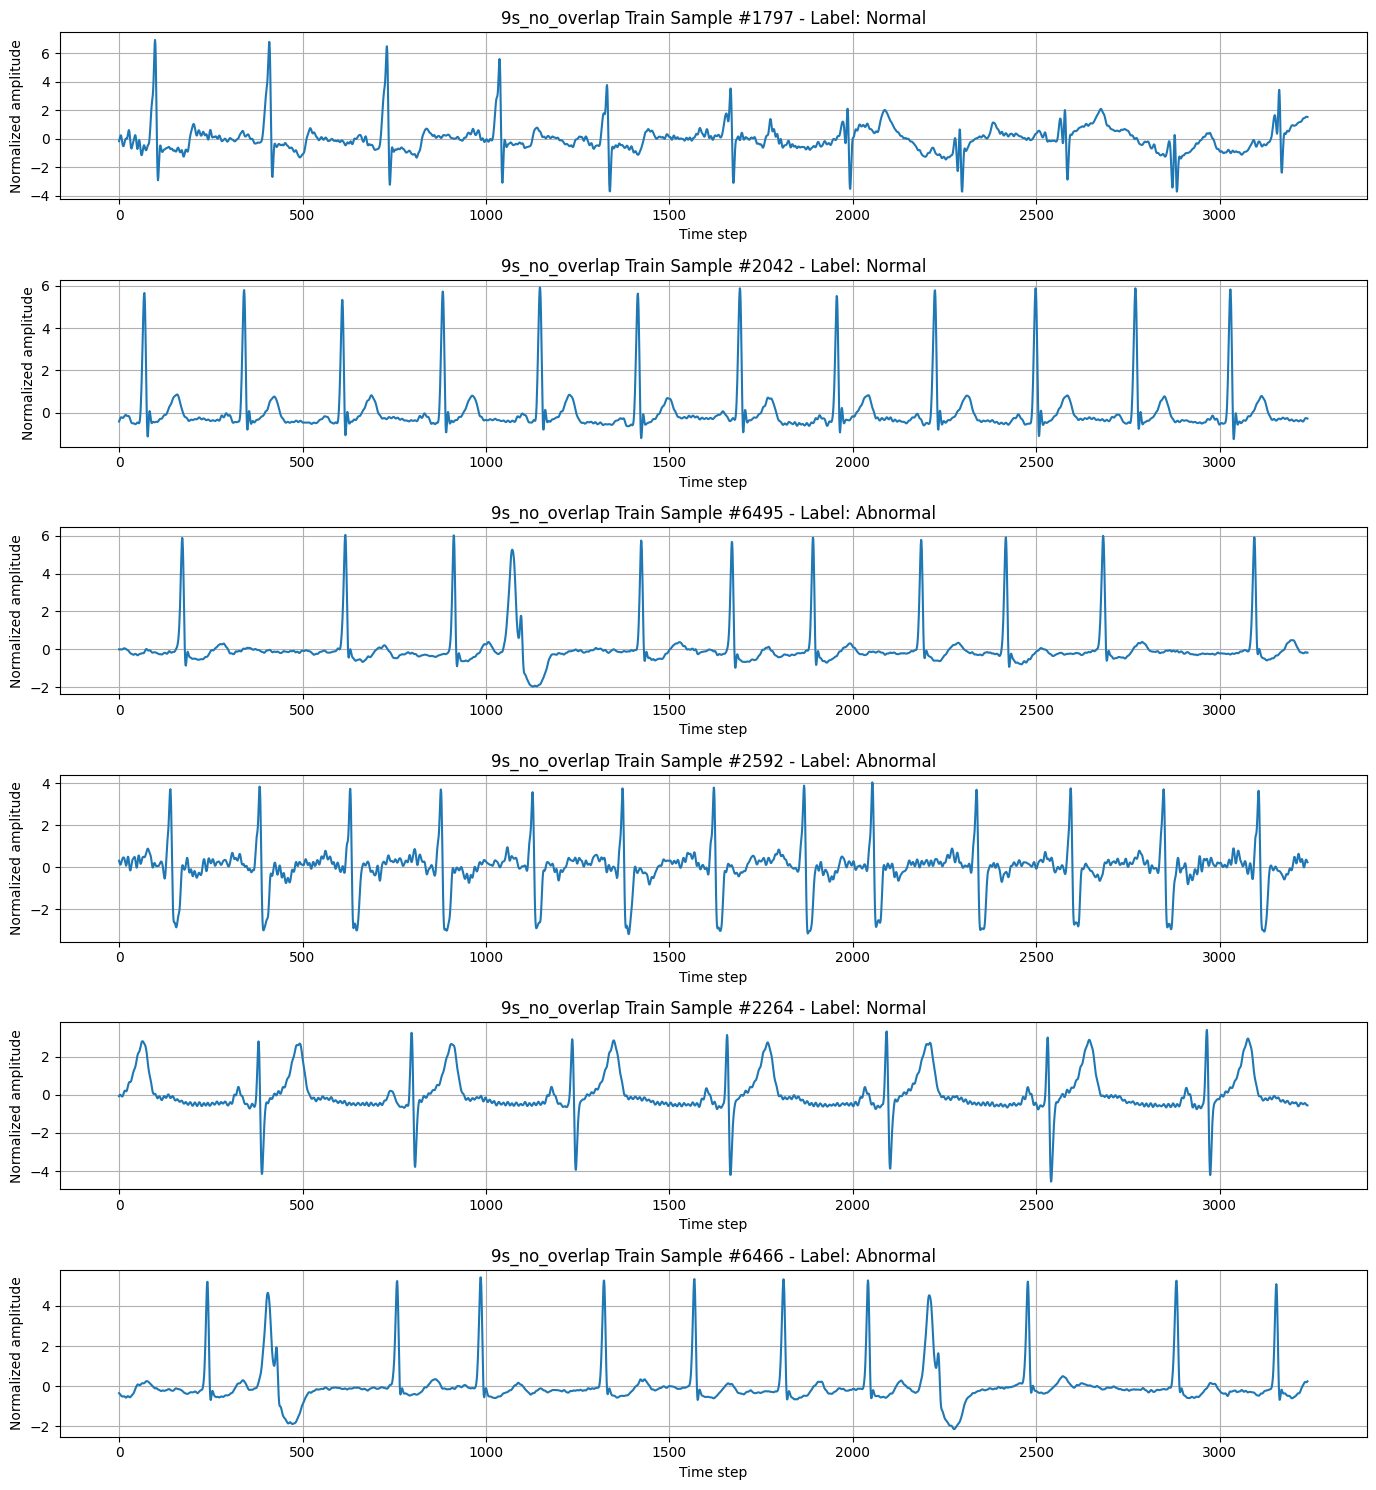


Class weights: {0: 0.99113197704747, 1: 1.009028146574615}


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ ecg_input (InputLayer)          │ (None, 3240, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 3240, 32)       │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 3240, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_6 (MaxPooling1D)  │ (None, 1620, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 1620, 64)       │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 1620, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_7 (MaxPooling1D)  │ (None, 810, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_10 (Conv1D)              │ (None, 810, 128)       │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 810, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 405, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_11 (Conv1D)              │ (None, 405, 256)       │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 405, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193,345 (755.25 KB)

 Trainable params: 192,385 (751.50 KB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 24s 115ms/step - accuracy: 0.8483 - auc: 0.9259 - loss: 0.3513 - val_accuracy: 0.7910 - val_auc: 0.9860 - val_loss: 0.8241 - learning_rate: 0.0010
Epoch 2/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 49ms/step - accuracy: 0.8880 - auc: 0.9548 - loss: 0.2709 - val_accuracy: 0.7910 - val_auc: 0.8229 - val_loss: 1.1121 - learning_rate: 0.0010
Epoch 3/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.8983 - auc: 0.9638 - loss: 0.2413 - val_accuracy: 0.8600 - val_auc: 0.9845 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 4/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9093 - auc: 0.9688 - loss: 0.2234 - val_accuracy: 0.7890 - val_auc: 0.9873 - val_loss: 0.3770 - learning_rate: 0.0010
Epoch 5/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.9101 - auc: 0.9699 - loss: 0.2172 - val_accuracy: 0.9580 - val_auc: 0.9888 - val_loss: 0.1825 - learning_rate: 0.0010
Epoch 6/15
119/119 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.9184 -

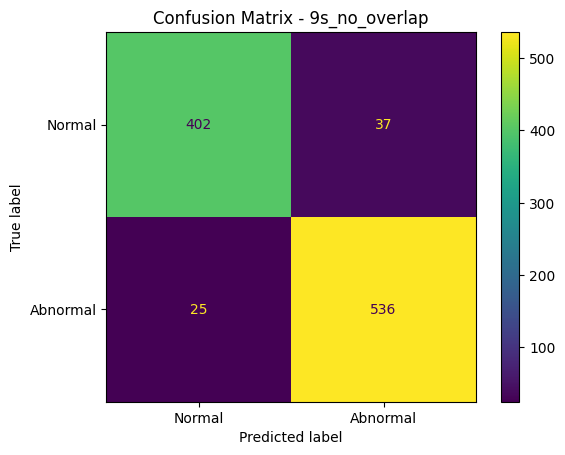

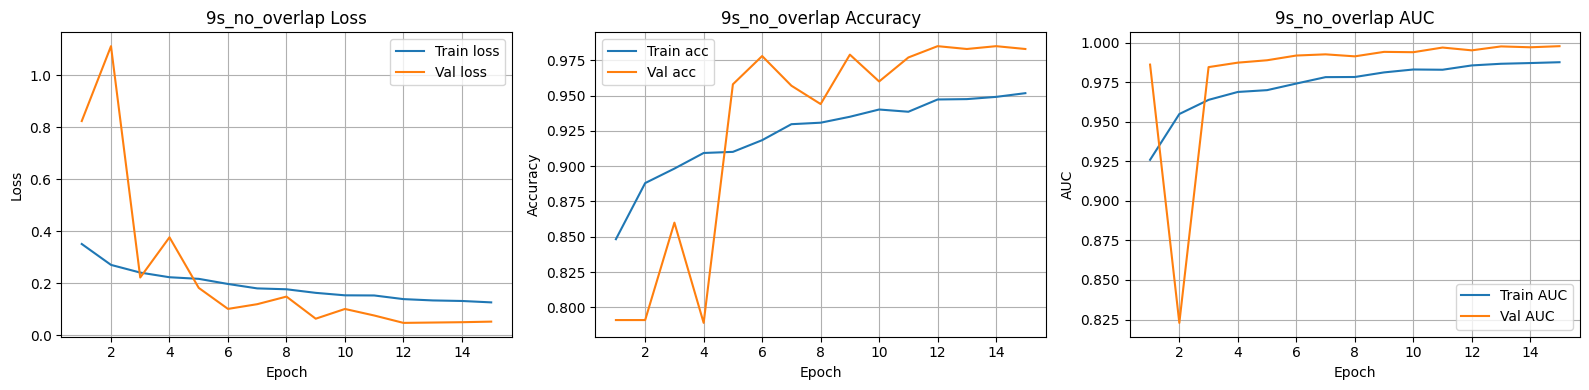

In [ ]:
all_results = {}

for window_name, cfg in WINDOW_CONFIGS.items():
    all_results[window_name] = run_experiment(
        window_name=window_name,
        window_seconds=cfg["window_seconds"],
        stride_seconds=cfg["stride_seconds"],
        epochs=15,
        batch_size=64
    )

## 11. Tổng hợp kết quả
Sau khi `all_results` đã có dữ liệu, phần này gom metric thành `results_df` để so sánh các window size.

Bảng kết quả cho biết số sample train/validation/test và các metric chính. Các biểu đồ phía sau giúp nhìn nhanh window size nào cân bằng hơn giữa accuracy, precision, recall và F1-score.


In [ ]:
summary_rows = []

for name, res in all_results.items():
    summary_rows.append({
        "window_name": res["window_name"],
        "window_seconds": res["window_seconds"],
        "window_samples": res["window_samples"],
        "stride_seconds": res["stride_seconds"],
        "train_samples": res["train_samples"],
        "val_samples": res["val_samples"],
        "test_samples": res["test_samples"],
        "accuracy": res["accuracy"],
        "precision": res["precision"],
        "recall": res["recall"],
        "f1_score": res["f1_score"]
    })

results_df = pd.DataFrame(summary_rows).sort_values(by="window_seconds")
results_df

,window_name,window_seconds,window_samples,stride_seconds,train_samples,val_samples,test_samples,accuracy,precision,recall,f1_score
0,0.75s_no_overlap,0.75,270,0.75,79043,11114,10736,0.898566,0.849312,0.933773,0.889543
1,4.5s_no_overlap,4.50,1620,4.50,15238,2004,2004,0.937625,0.940896,0.940000,0.940448
2,9s_no_overlap,9.00,3240,9.00,7600,1000,1000,0.938000,0.935428,0.955437,0.945326


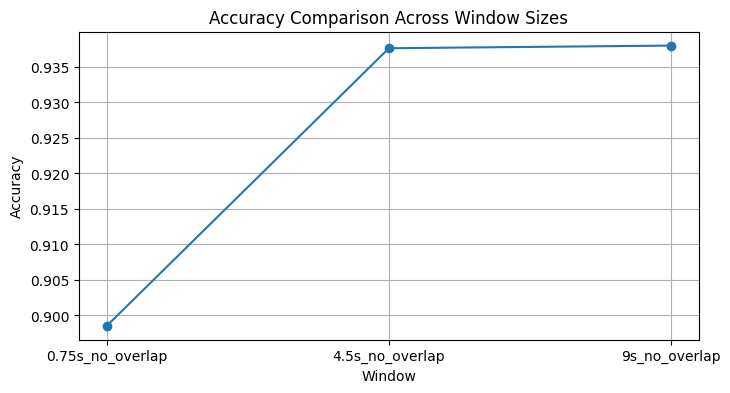

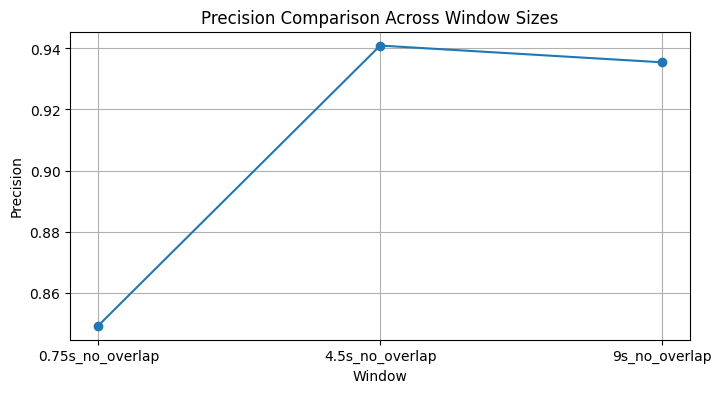

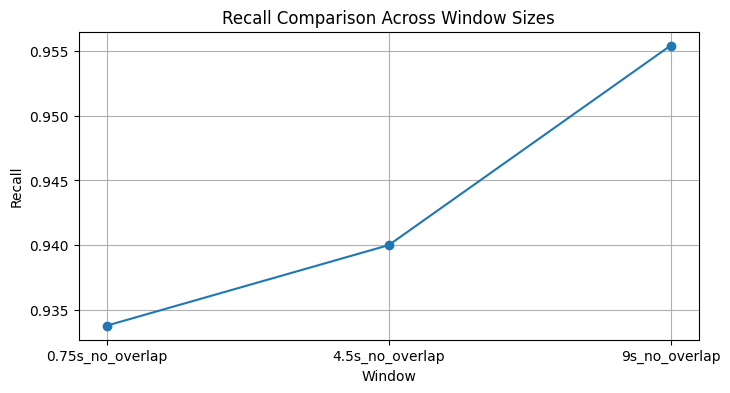

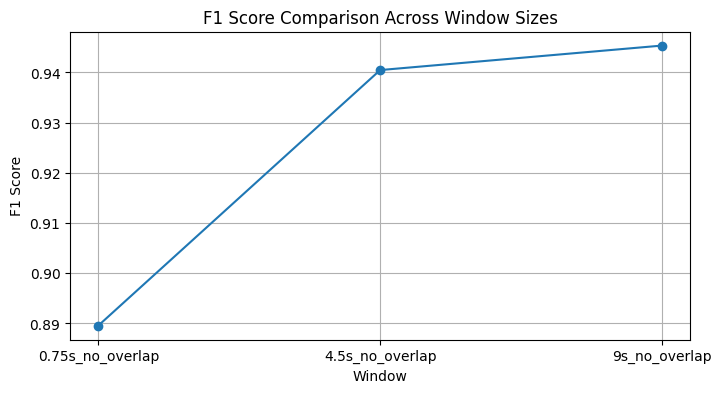

In [ ]:
metric_cols = ["accuracy", "precision", "recall", "f1_score"]

for metric in metric_cols:
    plt.figure(figsize=(8, 4))
    plt.plot(results_df["window_name"], results_df[metric], marker='o')
    plt.title(f"{metric.replace('_', ' ').title()} Comparison Across Window Sizes")
    plt.xlabel("Window")
    plt.ylabel(metric.replace('_', ' ').title())
    plt.grid(True)
    plt.show()

## 12. Bảng total thủ công (tùy chọn)
Cell cuối tạo một bảng có header hai tầng cho tổng số sample theo window size và split.

Các giá trị hiện tại là placeholder bằng `0`. Chỉ dùng cell này khi cần nhập hoặc thay bằng tổng đã tính từ kết quả thực nghiệm; nếu chỉ cần so sánh model thì đọc `results_df` ở phần 11 là đủ.


In [ ]:
import pandas as pd

# =========================
# Ví dụ: thay các số này bằng tổng thật của bạn
# =========================
total_45_train = 0
total_45_val   = 0
total_45_test  = 0

total_9_train  = 0
total_9_val    = 0
total_9_test   = 0

# =========================
# Tạo bảng dạng Excel với header 2 tầng
# =========================
columns = pd.MultiIndex.from_tuples([
    ("4.5s", "train"),
    ("4.5s", "val"),
    ("4.5s", "test"),
    ("9s",   "train"),
    ("9s",   "val"),
    ("9s",   "test"),
])

summary_df = pd.DataFrame(
    [[
        total_45_train, total_45_val, total_45_test,
        total_9_train, total_9_val, total_9_test
    ]],
    index=["total"],
    columns=columns
)

display(summary_df)

4.5s             9s         
      train val test train val test
total     0   0    0     0   0    0